## Упражнения

Загрузите следующие два временных ряда.

In [2]:
import requests
import numpy as np
from io import BytesIO

# Load the first time series
response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts1.npy?download=1")
response.raise_for_status()
smoothing_ts1 = np.load(BytesIO(response.content))
print(len(smoothing_ts1))

# Load the second time series
response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts4_4.npy?download=1")
response.raise_for_status()
smoothing_ts2 = np.load(BytesIO(response.content))
print(len(smoothing_ts2))

144
1000


Используя то, что вы узнали в этой и предыдущих лекциях, выполните следующие действия.

1. Создайте две временные переменные с именами `mytime1` и `mytime2`, которые начинаются с 0 и имеют такую ​​же длину, как и каждый набор данных.
2. Разделите каждый набор данных на обучающий и тестовый наборы (в качестве теста используйте последние 5 наблюдений).
3. Определите тренд и сезонность, если они присутствуют.
4. Определите, являются ли тренд и/или сезонность аддитивными или мультипликативными, если они присутствуют.
5. Создайте сглаженную модель на обучающем наборе и используйте ее для прогнозирования на тестовом наборе.
6. Рассчитайте MSE на тестовых данных.
7. Нанесите на график обучающие данные, тестовые данные и прогноз вашей модели для каждого набора данных.

**Упражнение:**

Estimated seasonal periods: 12 166


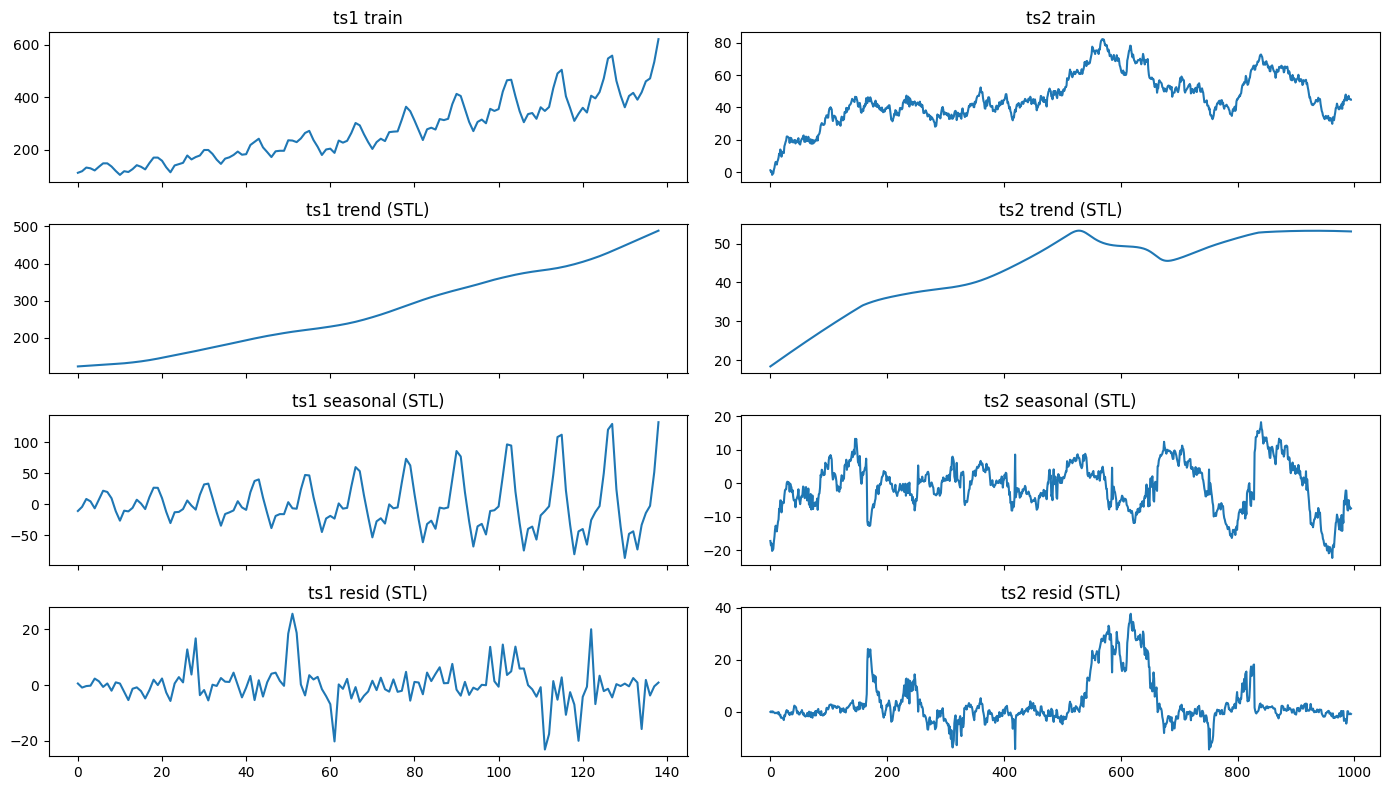

ts1 best: trend=add, seasonal=add, MSE=106.267
ts2 best: trend=None, seasonal=None, MSE=3.182


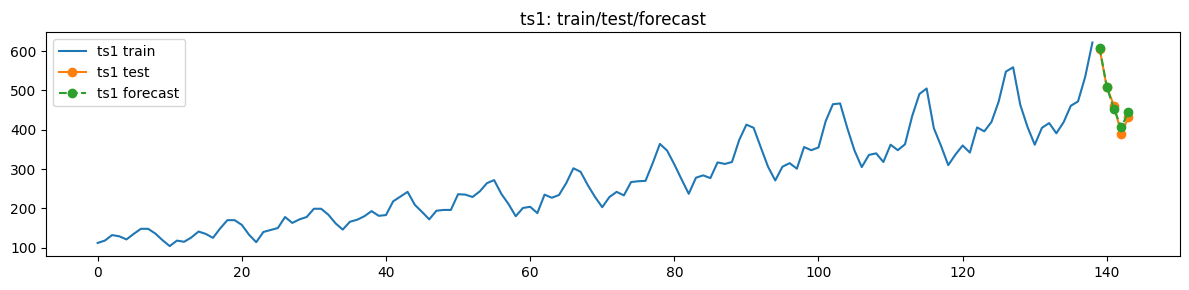

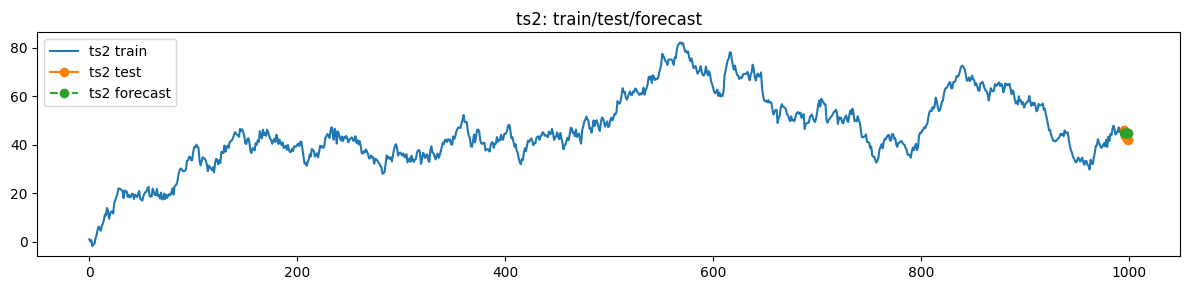

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")

# Анализ и сглаживание для двух рядов
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def _dominant_period_fft(y, min_period: int = 2, max_period: int | None = 200):
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    if len(y) < 4:
        return None

    # Линейное детрендирование, чтобы частота тренда не «победила» сезонность
    t = np.arange(len(y))
    slope, intercept = np.polyfit(t, y, 1)
    y = y - (slope * t + intercept)

    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(len(y))
    mask = freqs > 0
    if not np.any(mask):
        return None
    periods = 1.0 / freqs[mask]
    mags = np.abs(fft_vals[mask])

    if max_period is None:
        max_period = int(periods.max())
    ok = (periods >= min_period) & (periods <= max_period)
    if not np.any(ok):
        return None
    period = periods[ok][int(np.argmax(mags[ok]))]
    return int(round(period))

def _split_train_test(ts, test_horizon: int = 5):
    ts = np.asarray(ts, dtype=float)
    return ts[:-test_horizon], ts[-test_horizon:]

def _mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))

def _fit_best_holtwinters(train, test, seasonal_periods: int | None):
    candidates = []
    for trend in [None, "add"]:
        for seasonal in [None, "add", "mul"]:
            if seasonal is None:
                sp = None
            else:
                sp = seasonal_periods
            if seasonal == "mul" and np.any(train <= 0):
                continue
            if sp is not None and (sp < 2 or len(train) < 2 * sp):
                continue
            try:
                model = ExponentialSmoothing(
                    train,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=sp,
                    initialization_method="estimated",
                )
                fit = model.fit(optimized=True)
                pred = fit.forecast(len(test))
                candidates.append((_mse(test, pred), trend, seasonal, pred))
            except Exception:
                continue
    if not candidates:
        raise RuntimeError("No valid Holt-Winters configuration found")
    candidates.sort(key=lambda x: x[0])
    return candidates[0]

# 1) Временные переменные
mytime1 = np.arange(len(smoothing_ts1))
mytime2 = np.arange(len(smoothing_ts2))

# 2) train/test
ts1_train, ts1_test = _split_train_test(smoothing_ts1, test_horizon=5)
ts2_train, ts2_test = _split_train_test(smoothing_ts2, test_horizon=5)

# 3) Оценка периодов сезонности + STL для понимания тренда/сезонности
p1 = _dominant_period_fft(ts1_train, min_period=2, max_period=min(200, len(ts1_train) // 2))
p2 = _dominant_period_fft(ts2_train, min_period=2, max_period=min(200, len(ts2_train) // 2))
print("Estimated seasonal periods:", p1, p2)

stl1 = STL(ts1_train, period=p1 if p1 else 12, robust=True).fit()
stl2 = STL(ts2_train, period=p2 if p2 else 12, robust=True).fit()

fig, axes = plt.subplots(4, 2, figsize=(14, 8), sharex="col")
axes[0, 0].plot(ts1_train); axes[0, 0].set_title("ts1 train")
axes[1, 0].plot(stl1.trend); axes[1, 0].set_title("ts1 trend (STL)")
axes[2, 0].plot(stl1.seasonal); axes[2, 0].set_title("ts1 seasonal (STL)")
axes[3, 0].plot(stl1.resid); axes[3, 0].set_title("ts1 resid (STL)")

axes[0, 1].plot(ts2_train); axes[0, 1].set_title("ts2 train")
axes[1, 1].plot(stl2.trend); axes[1, 1].set_title("ts2 trend (STL)")
axes[2, 1].plot(stl2.seasonal); axes[2, 1].set_title("ts2 seasonal (STL)")
axes[3, 1].plot(stl2.resid); axes[3, 1].set_title("ts2 resid (STL)")
plt.tight_layout(); plt.show()

# 4–7) Подбор аддитивной/мультипликативной модели Holt-Winters по MSE на тесте
mse1, trend1, seas1, pred1 = _fit_best_holtwinters(ts1_train, ts1_test, seasonal_periods=(p1 if p1 else 12))
mse2, trend2, seas2, pred2 = _fit_best_holtwinters(ts2_train, ts2_test, seasonal_periods=(p2 if p2 else 12))

print(f"ts1 best: trend={trend1}, seasonal={seas1}, MSE={mse1:.3f}")
print(f"ts2 best: trend={trend2}, seasonal={seas2}, MSE={mse2:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(mytime1[:-5], ts1_train, label="ts1 train")
ax.plot(mytime1[-5:], ts1_test, "o-", label="ts1 test")
ax.plot(mytime1[-5:], pred1, "o--", label="ts1 forecast")
ax.set_title("ts1: train/test/forecast")
ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(mytime2[:-5], ts2_train, label="ts2 train")
ax.plot(mytime2[-5:], ts2_test, "o-", label="ts2 test")
ax.plot(mytime2[-5:], pred2, "o--", label="ts2 forecast")
ax.set_title("ts2: train/test/forecast")
ax.legend(); plt.tight_layout(); plt.show()


**Пояснения для упражнения:**

Тренд/сезонность видны по STL-компонентам.<br>

Аддитивность/мультипликативность выбрана по минимальному MSE на тесте среди нескольких конфигураций Holt-Winters.